# 03 â€” Analysis & Visualization

Reads `outputs/annotated.csv` (with human overrides filled in) and produces the paper-ready charts and metrics table.

In [64]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
ROOT = Path('..')
ANNOTATED_CSV = ROOT / 'outputs' / 'annotated.csv'

## 1. Load and prepare data

In [65]:
df = pd.read_csv(ANNOTATED_CSV)

# Effective score = human override if provided, else LLM judge
df['complexity_score'] = df['human_complexity_score'].combine_first(df['llm_complexity_score'])
df['faithful'] = df['human_faithful'].combine_first(df['llm_faithful'])

# Keep only rows with valid scores (exclude extraction errors, parse errors)
valid = df[
    df['complexity_score'].between(1, 5) &
    df['faithful'].isin([0, 1])
].copy()

print(f'Total rows: {len(df)} | Valid for analysis: {len(valid)}')
valid.groupby('period')[['complexity_score', 'faithful']].describe().round(2)

Total rows: 577 | Valid for analysis: 577


complexity_score                                         \
                            count  mean   std  min   25%  50%   75%  max   
period                                                                     
great_moderation            156.0  2.49  1.18  1.0  1.75  2.0  3.00  5.0   
post_covid                  222.0  2.60  1.29  1.0  2.00  2.0  3.75  5.0   
post_crisis_zlb             199.0  2.47  1.07  1.0  2.00  2.0  3.00  5.0   

                 faithful                                       
                    count  mean   std  min  25%  50%  75%  max  
period                                                          
great_moderation    156.0  0.68  0.47  0.0  0.0  1.0  1.0  1.0  
post_covid          222.0  0.66  0.48  0.0  0.0  1.0  1.0  1.0  
post_crisis_zlb     199.0  0.67  0.47  0.0  0.0  1.0  1.0  1.0

In [66]:
len(df['passage_id'].unique())

201

## 2. Overall faithfulness rate

In [67]:
overall_faithful = valid['faithful'].mean()
print(f'Overall faithfulness rate: {overall_faithful:.1%} ({int(valid["faithful"].sum())}/{len(valid)} triples)')

Overall faithfulness rate: 66.9% (386/577 triples)


## 3. Faithfulness by complexity bucket (bar chart)

**Hypothesis:** monotonically decreasing â€” more complex passages yield less faithful extractions.

,complexity_score,faithful_rate,count
0,1.0,0.795455,132
1,2.0,0.692308,169
2,3.0,0.662500,160
3,4.0,0.506849,73
4,5.0,0.488372,43


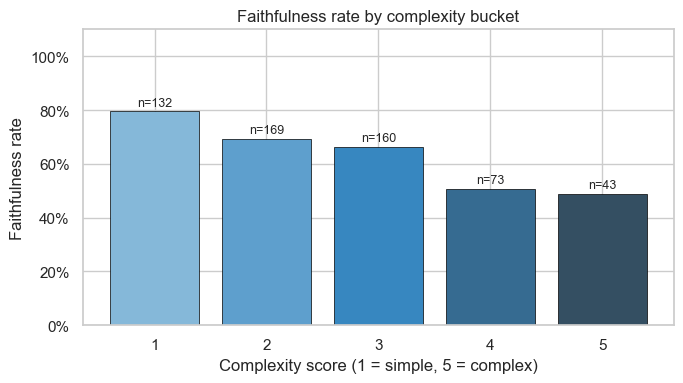

In [68]:
by_complexity = (
    valid.groupby('complexity_score')['faithful']
    .agg(faithful_rate='mean', count='count')
    .reset_index()
)
display(by_complexity)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(by_complexity['complexity_score'], by_complexity['faithful_rate'],
               color=sns.color_palette('Blues_d', 5), edgecolor='black', linewidth=0.5)
# Annotate with n
for bar, n in zip(bars, by_complexity['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'n={n}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Complexity score (1 = simple, 5 = complex)')
ax.set_ylabel('Faithfulness rate')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.1)
ax.set_title('Faithfulness rate by complexity bucket')
plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures' / 'fig_faithfulness_by_complexity.png', dpi=150)
plt.show()

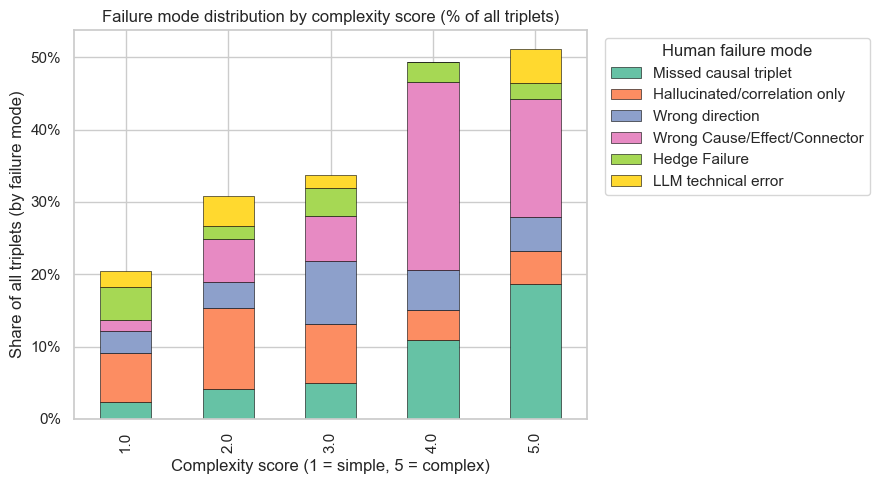

In [69]:
# Use only human-coded failure modes for non-faithful triples
errors = valid[(valid['faithful'] == 0) & (valid['human_failure_mode'].notna())].copy()

error_mix = (
    errors.groupby(['complexity_score', 'human_failure_mode'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

error_names = {
    0: 'Missed causal triplet',
    1: 'Hallucinated/correlation only',
    2: 'Wrong direction',
    3: 'Wrong Cause/Effect/Connector',
    4: 'Hedge Failure',
    5: 'LLM technical error',
}

# Rename numeric failure-mode codes for cleaner legend labels
error_mix_named = error_mix.rename(columns=lambda x: error_names.get(int(x), str(x)))

# Fixed order + fixed hex colors for cross-chart consistency
mode_order = [
    'Missed causal triplet',
    'Hallucinated/correlation only',
    'Wrong direction',
    'Wrong Cause/Effect/Connector',
    'Hedge Failure',
    'LLM technical error',
]
mode_color_map = {
    'Missed causal triplet': '#66c2a5',
    'Hallucinated/correlation only': '#fc8d62',
    'Wrong direction': '#8da0cb',
    'Wrong Cause/Effect/Connector': '#e78ac3',
    'Hedge Failure': '#a6d854',
    'LLM technical error': '#ffd92f',
}
error_mix_named = error_mix_named.reindex(columns=mode_order, fill_value=0)
plot_colors = [mode_color_map[c] for c in error_mix_named.columns]

# Normalize within each complexity score so bars show composition
# Normalize by total triplets per complexity score (not just failures)
all_triplets_per_complexity = valid.groupby('complexity_score').size()
error_mix_pct = error_mix_named.div(all_triplets_per_complexity, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
error_mix_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=plot_colors,
    edgecolor='black',
    linewidth=0.4,
)

ax.set_xlabel('Complexity score (1 = simple, 5 = complex)')
ax.set_ylabel('Share of all triplets (by failure mode)')
ax.set_title('Failure mode distribution by complexity score (% of all triplets)')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend(title='Human failure mode', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures' / 'fig_human_failure_modes_by_complexity.png', dpi=150)
plt.show()

In [88]:
error_mix_named

human_failure_mode,Missed causal triplet,Hallucinated/correlation only,Wrong direction,Wrong Cause/Effect/Connector,Hedge Failure,LLM technical error
complexity_score,,,,,,
1.0,3,9,4,2,6,3
2.0,7,19,6,10,3,7
3.0,8,13,14,10,6,3
4.0,8,3,4,19,2,0
5.0,8,2,2,7,1,2


,complexity_score,faithful_rate,count
0,1.0,0.833333,126
1,2.0,0.754839,155
2,3.0,0.711409,149
3,4.0,0.569231,65
4,5.0,0.636364,33


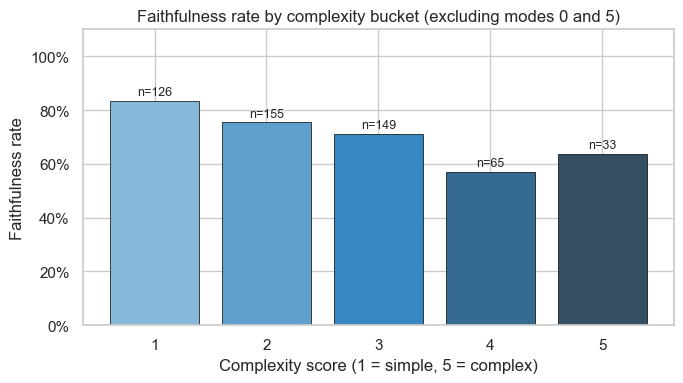

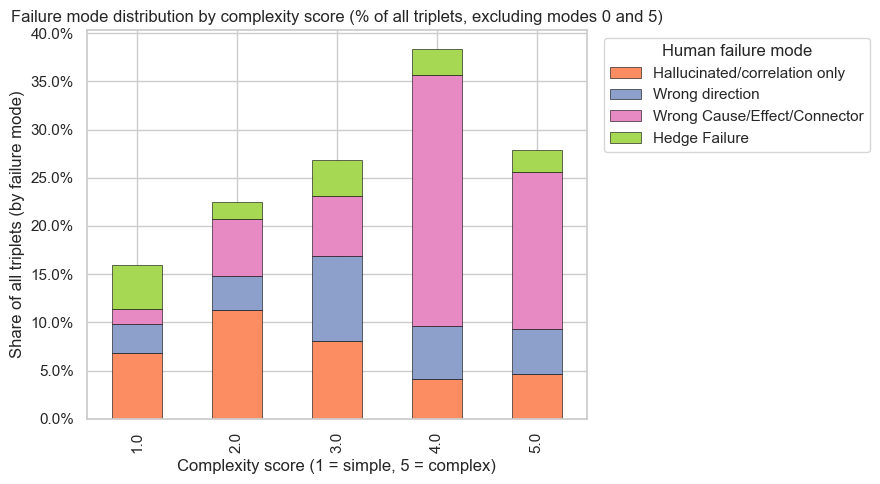

In [70]:
# New analysis (without changing existing cells): exclude rows where human_failure_mode is 0 or 5
valid_no_mode05 = valid[(valid['human_failure_mode'].isna()) | (~valid['human_failure_mode'].isin([0, 5]))].copy()

# 1) Faithfulness by complexity (bar chart)
by_complexity_no_mode05 = (
    valid_no_mode05.groupby('complexity_score')['faithful']
    .agg(faithful_rate='mean', count='count')
    .reset_index()
)
display(by_complexity_no_mode05)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    by_complexity_no_mode05['complexity_score'],
    by_complexity_no_mode05['faithful_rate'],
    color=sns.color_palette('Blues_d', 5),
    edgecolor='black',
    linewidth=0.5,
)
for bar, n in zip(bars, by_complexity_no_mode05['count']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'n={n}',
        ha='center',
        va='bottom',
        fontsize=9,
    )
ax.set_xlabel('Complexity score (1 = simple, 5 = complex)')
ax.set_ylabel('Faithfulness rate')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.1)
ax.set_title('Faithfulness rate by complexity bucket (excluding modes 0 and 5)')
plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures' / 'fig_faithfulness_by_complexity_no_mode0_5.png', dpi=150)
plt.show()

# 2) Human failure mode by complexity (stacked bar chart, proportions)
errors_no_mode05 = valid[
    (valid['faithful'] == 0)
    & (valid['human_failure_mode'].notna())
    & (~valid['human_failure_mode'].isin([0, 5]))
].copy()

error_mix_no_mode05 = (
    errors_no_mode05.groupby(['complexity_score', 'human_failure_mode'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

error_names_local = {
    0: 'Missed causal triplet',
    1: 'Hallucinated/correlation only',
    2: 'Wrong direction',
    3: 'Wrong Cause/Effect/Connector',
    4: 'Hedge Failure',
    5: 'LLM technical error',
}

error_mix_named_no_mode05 = error_mix_no_mode05.rename(
    columns=lambda x: error_names_local.get(int(x), str(x))
)

# Same fixed order + same fixed hex colors as the original stacked chart
mode_order = [
    'Missed causal triplet',
    'Hallucinated/correlation only',
    'Wrong direction',
    'Wrong Cause/Effect/Connector',
    'Hedge Failure',
    'LLM technical error',
]
mode_color_map = {
    'Missed causal triplet': '#66c2a5',
    'Hallucinated/correlation only': '#fc8d62',
    'Wrong direction': '#8da0cb',
    'Wrong Cause/Effect/Connector': '#e78ac3',
    'Hedge Failure': '#a6d854',
    'LLM technical error': '#ffd92f',
}

# Reindex enforces stable ordering; drop modes 0 and 5 for this filtered view
error_mix_named_no_mode05 = error_mix_named_no_mode05.reindex(columns=mode_order, fill_value=0)
error_mix_named_no_mode05 = error_mix_named_no_mode05.drop(
    columns=['Missed causal triplet', 'LLM technical error'],
    errors='ignore',
)
plot_colors_no_mode05 = [mode_color_map[c] for c in error_mix_named_no_mode05.columns]

all_triplets_per_complexity_no_mode05 = valid.groupby('complexity_score').size()
error_mix_pct_no_mode05 = error_mix_named_no_mode05.div(
    all_triplets_per_complexity_no_mode05,
    axis=0,
)

fig, ax = plt.subplots(figsize=(9, 5))
error_mix_pct_no_mode05.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=plot_colors_no_mode05,
    edgecolor='black',
    linewidth=0.4,
)

ax.set_xlabel('Complexity score (1 = simple, 5 = complex)')
ax.set_ylabel('Share of all triplets (by failure mode)')
ax.set_title('Failure mode distribution by complexity score (% of all triplets, excluding modes 0 and 5)')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend(title='Human failure mode', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures' / 'fig_human_failure_modes_by_complexity_no_mode0_5.png', dpi=150)
plt.show()

In [83]:
by_complexity_no_mode05['a'] = by_complexity_no_mode05['faithful_rate'] * by_complexity_no_mode05['count']
by_complexity_no_mode05

,complexity_score,faithful_rate,count,a
0,1.0,0.833333,126,105.0
1,2.0,0.754839,155,117.0
2,3.0,0.711409,149,106.0
3,4.0,0.569231,65,37.0
4,5.0,0.636364,33,21.0


,complexity_score,faithful_rate,count
0,1.0,0.912698,126
1,2.0,0.812903,155
2,3.0,0.845638,149
3,4.0,0.661538,65
4,5.0,0.727273,33


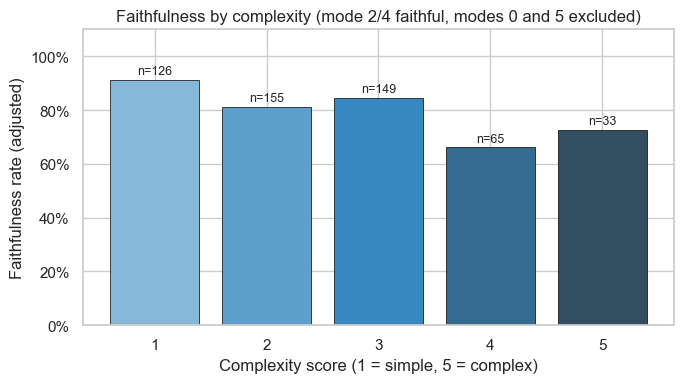

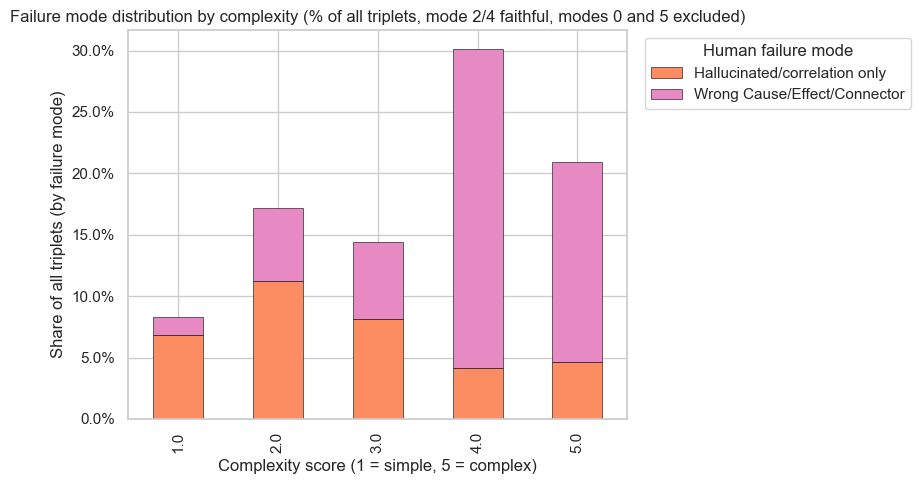

In [86]:
# Alternate analysis: treat human_failure_mode 2 or 4 as faithful,
# while excluding rows where human_failure_mode is 0 or 5
alt = valid.copy()

# Re-label faithfulness for specified human failure modes
alt['faithful_alt'] = alt['faithful']
alt.loc[alt['human_failure_mode'].isin([2, 4]), 'faithful_alt'] = 1

alt_no_mode05 = alt[(alt['human_failure_mode'].isna()) | (~alt['human_failure_mode'].isin([0, 5]))].copy()

# 1) Faithfulness by complexity (bar chart) with adjusted labeling
by_complexity_alt = (
    alt_no_mode05.groupby('complexity_score')['faithful_alt']
    .agg(faithful_rate='mean', count='count')
    .reset_index()
)
display(by_complexity_alt)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    by_complexity_alt['complexity_score'],
    by_complexity_alt['faithful_rate'],
    color=sns.color_palette('Blues_d', 5),
    edgecolor='black',
    linewidth=0.5,
)
for bar, n in zip(bars, by_complexity_alt['count']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'n={n}',
        ha='center',
        va='bottom',
        fontsize=9,
    )
ax.set_xlabel('Complexity score (1 = simple, 5 = complex)')
ax.set_ylabel('Faithfulness rate (adjusted)')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.1)
ax.set_title('Faithfulness by complexity (mode 2/4 faithful, modes 0 and 5 excluded)')
plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures' / 'fig_faithfulness_by_complexity_mode24_faithful_no_mode0_5.png', dpi=150)
plt.show()

# 2) Human failure mode stacked chart under adjusted labeling
errors_alt = alt[
    (alt['faithful_alt'] == 0)
    & (alt['human_failure_mode'].notna())
    & (~alt['human_failure_mode'].isin([0, 5]))
].copy()

error_mix_alt = (
    errors_alt.groupby(['complexity_score', 'human_failure_mode'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

error_names_alt = {
    0: 'Missed causal triplet',
    1: 'Hallucinated/correlation only',
    2: 'Wrong direction',
    3: 'Wrong Cause/Effect/Connector',
    4: 'Hedge Failure',
    5: 'LLM technical error',
}

error_mix_named_alt = error_mix_alt.rename(columns=lambda x: error_names_alt.get(int(x), str(x)))

# Keep identical ordering and colors as existing stacked charts
mode_order = [
    'Missed causal triplet',
    'Hallucinated/correlation only',
    'Wrong direction',
    'Wrong Cause/Effect/Connector',
    'Hedge Failure',
    'LLM technical error',
]
mode_color_map = {
    'Missed causal triplet': '#66c2a5',
    'Hallucinated/correlation only': '#fc8d62',
    'Wrong direction': '#8da0cb',
    'Wrong Cause/Effect/Connector': '#e78ac3',
    'Hedge Failure': '#a6d854',
    'LLM technical error': '#ffd92f',
}

error_mix_named_alt = error_mix_named_alt.reindex(columns=mode_order, fill_value=0)
error_mix_named_alt = error_mix_named_alt.drop(
    columns=['Missed causal triplet', 'Wrong direction', 'Hedge Failure', 'LLM technical error'],
    errors='ignore',
)
plot_colors_alt = [mode_color_map[c] for c in error_mix_named_alt.columns]

all_triplets_per_complexity_alt = valid.groupby('complexity_score').size()
error_mix_pct_alt = error_mix_named_alt.div(all_triplets_per_complexity_alt, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
error_mix_pct_alt.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=plot_colors_alt,
    edgecolor='black',
    linewidth=0.4,
)

ax.set_xlabel('Complexity score (1 = simple, 5 = complex)')
ax.set_ylabel('Share of all triplets (by failure mode)')
ax.set_title('Failure mode distribution by complexity (% of all triplets, mode 2/4 faithful, modes 0 and 5 excluded)')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend(title='Human failure mode', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures' / 'fig_human_failure_modes_by_complexity_mode24_faithful_no_mode0_5.png', dpi=150)
plt.show()

In [87]:
by_complexity_alt['a'] = by_complexity_alt['faithful_rate'] * by_complexity_alt['count']
by_complexity_alt.sum()

complexity_score     15.00000
faithful_rate         3.96005
count               528.00000
a                   434.00000
dtype: float64

## 4. Faithfulness by economic period

,period,faithful_rate,count
0,great_moderation,0.679487,156
1,post_crisis_zlb,0.673367,199
2,post_covid,0.657658,222


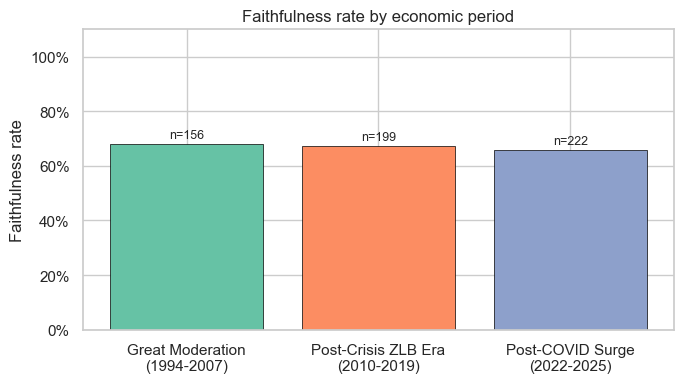

In [72]:
from src.config import load_config

periods_cfg = load_config()['periods']
PERIOD_ORDER = list(periods_cfg.keys())
PERIOD_LABELS = {
    key: f"{cfg['label']}\n({cfg['start_year']}-{cfg['end_year']})"
    for key, cfg in periods_cfg.items()
}

by_period = (
    valid.groupby('period')['faithful']
    .agg(faithful_rate='mean', count='count')
    .reindex(PERIOD_ORDER)
    .reset_index()
)
display(by_period)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    [PERIOD_LABELS[p] for p in by_period['period']],
    by_period['faithful_rate'],
    color=sns.color_palette('Set2', 3), edgecolor='black', linewidth=0.5,
)
for bar, n in zip(bars, by_period['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'n={n}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Faithfulness rate')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.1)
ax.set_title('Faithfulness rate by economic period')
plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures' / 'fig_faithfulness_by_period.png', dpi=150)
plt.show()

## 5. Failure mode distribution by period

**Hypothesis:** Hedge Failure is more prevalent in the Post-COVID period.

failure_mode_name,Missed causal triplet,Hallucinated/correlation only,Wrong direction,Wrong Cause/Effect/Connector,Hedge Failure,LLM technical error
period,,,,,,
Great Moderation\n(1994-2007),0.6,7.7,7.1,9.0,6.4,1.3
Post-Crisis ZLB Era\n(2010-2019),8.0,7.0,4.0,7.5,4.0,2.0
Post-COVID Surge\n(2022-2025),7.7,9.0,5.0,8.6,0.0,4.1


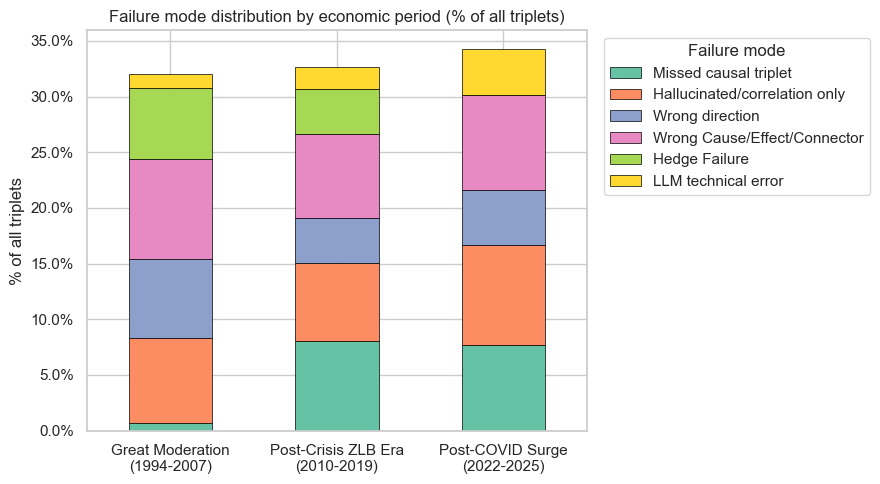

In [73]:
# Use effective failure mode: human override or LLM judge
failures = valid[valid['faithful'] == 0].copy()

# Resolve failure mode: prefer human annotation if provided
# (Human annotators should add a 'human_failure_mode' column; fall back to LLM)
if 'human_failure_mode' in failures.columns:
    failures['failure_mode'] = failures['human_failure_mode'].combine_first(failures['llm_failure_mode'])
else:
    failures['failure_mode'] = failures['llm_failure_mode']

# Match naming and color conventions used in other failure-mode charts
error_names_local = {
    0: 'Missed causal triplet',
    1: 'Hallucinated/correlation only',
    2: 'Wrong direction',
    3: 'Wrong Cause/Effect/Connector',
    4: 'Hedge Failure',
    5: 'LLM technical error',
}
failures['failure_mode_name'] = failures['failure_mode'].map(
    lambda x: error_names_local.get(int(x), str(x)) if pd.notna(x) else 'Unknown'
)

mode_order = [
    'Missed causal triplet',
    'Hallucinated/correlation only',
    'Wrong direction',
    'Wrong Cause/Effect/Connector',
    'Hedge Failure',
    'LLM technical error',
]

mode_color_map = {
    'Missed causal triplet': '#66c2a5',
    'Hallucinated/correlation only': '#fc8d62',
    'Wrong direction': '#8da0cb',
    'Wrong Cause/Effect/Connector': '#e78ac3',
    'Hedge Failure': '#a6d854',
    'LLM technical error': '#ffd92f',
}

failure_pivot = (
    failures.groupby(['period', 'failure_mode_name'])
    .size()
    .unstack(fill_value=0)
    .reindex(PERIOD_ORDER)
    .reindex(columns=mode_order, fill_value=0)
)

# Normalize by total triplets per period (not just failures)
all_triplets_per_period = valid.groupby('period').size().reindex(PERIOD_ORDER)
failure_pct = failure_pivot.div(all_triplets_per_period, axis=0)

# Now rename the index for display
failure_pct_display = failure_pct.rename(index=PERIOD_LABELS)
display((failure_pct_display * 100).round(1))

plot_colors = [mode_color_map[c] for c in failure_pct_display.columns]
ax = failure_pct_display.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5),
    color=plot_colors,
    edgecolor='black',
    linewidth=0.5,
)
ax.set_ylabel('% of all triplets')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_title('Failure mode distribution by economic period (% of all triplets)')
ax.legend(title='Failure mode', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures' / 'fig_failure_modes_by_period.png', dpi=150)
plt.show()


,period,mean_complexity,period_count,hedged_triplets,hedged_share_of_all_triples
0,great_moderation,2.49,156,80,0.513
1,post_crisis_zlb,2.47,199,87,0.437
2,post_covid,2.60,222,104,0.468


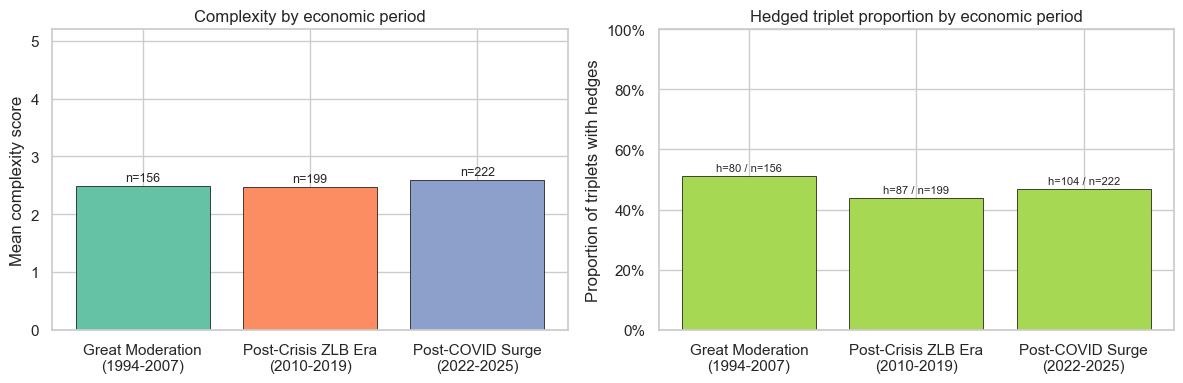

In [74]:
# Complexity per period and hedged-triplet analysis across periods
period_complexity = (
    valid.groupby('period')['complexity_score']
    .agg(mean_complexity='mean', period_count='count')
    .reindex(PERIOD_ORDER)
    .reset_index()
)

# Count triplets whose hedge field is populated with something other than 'none'
hedged = valid.copy()
hedged['has_hedge'] = (
    hedged['hedge']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
    .ne('none')
    & hedged['hedge'].notna()
)

hedge_period = (
    hedged.groupby('period')['has_hedge']
    .agg(hedged_triplets='sum')
    .reindex(PERIOD_ORDER)
    .reset_index()
)

period_analysis = period_complexity.merge(hedge_period, on='period', how='left')
period_analysis['hedged_share_of_all_triples'] = (
    period_analysis['hedged_triplets'] / period_analysis['period_count']
)

display(period_analysis.assign(
    mean_complexity=lambda d: d['mean_complexity'].round(2),
    hedged_share_of_all_triples=lambda d: d['hedged_share_of_all_triples'].round(3),
))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Average complexity by period
axes[0].bar(
    [PERIOD_LABELS[p] for p in period_analysis['period']],
    period_analysis['mean_complexity'],
    color=sns.color_palette('Set2', len(period_analysis)),
    edgecolor='black',
    linewidth=0.5,
)
for bar, n in zip(axes[0].patches, period_analysis['period_count']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f'n={n}',
        ha='center',
        va='bottom',
        fontsize=9,
    )
axes[0].set_ylabel('Mean complexity score')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 5.2)
axes[0].set_title('Complexity by economic period')

# Hedged triplets as a proportion of all triplets
hedge_color = '#a6d854'
axes[1].bar(
    [PERIOD_LABELS[p] for p in period_analysis['period']],
    period_analysis['hedged_share_of_all_triples'],
    color=hedge_color,
    edgecolor='black',
    linewidth=0.5,
)
for bar, hedge_count, total_triples in zip(
    axes[1].patches,
    period_analysis['hedged_triplets'],
    period_analysis['period_count'],
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'h={int(hedge_count)} / n={int(total_triples)}',
        ha='center',
        va='bottom',
        fontsize=8,
    )
axes[1].set_ylabel('Proportion of triplets with hedges')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Hedged triplet proportion by economic period')

plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures' / 'fig_complexity_and_hedged_triplets_by_period.png', dpi=150)
plt.show()

,hedge_group,triplet_count,faithfulness_rate,mean_complexity
0,No hedge,251,0.773,1.865
1,Hedged,259,0.741,3.077


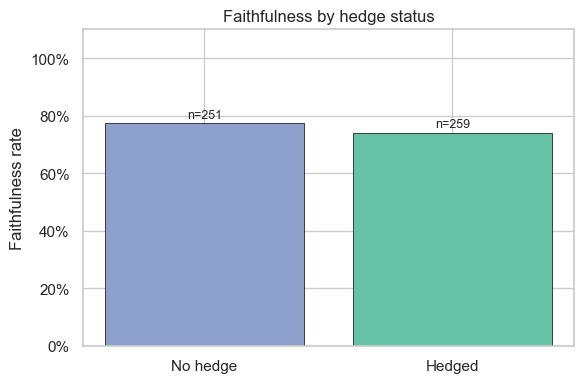

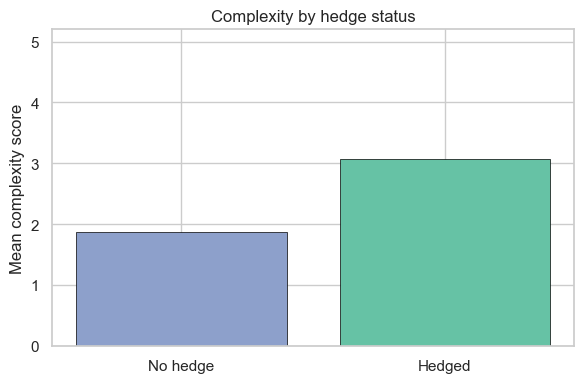

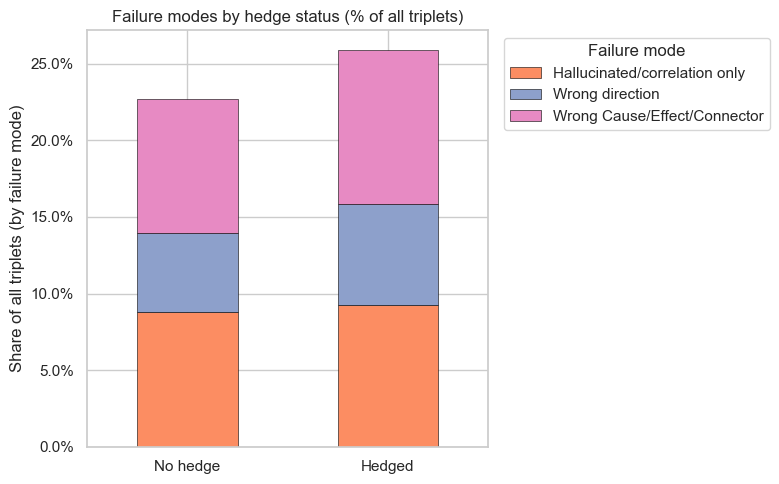

In [75]:
# Compare hedged vs non-hedged triplets: faithfulness, complexity, and failure modes
hedge_cmp = valid.copy()

# Exclude missed triplets, hedge failures, and technical errors
if 'human_failure_mode' in hedge_cmp.columns:
    hedge_cmp['failure_mode_resolved'] = hedge_cmp['human_failure_mode'].combine_first(hedge_cmp['llm_failure_mode'])
else:
    hedge_cmp['failure_mode_resolved'] = hedge_cmp['llm_failure_mode']
hedge_cmp['failure_mode_resolved'] = pd.to_numeric(hedge_cmp['failure_mode_resolved'], errors='coerce')
exclude_mask = hedge_cmp['faithful'].eq(0) & hedge_cmp['failure_mode_resolved'].isin([0, 4, 5])
hedge_cmp = hedge_cmp.loc[~exclude_mask].copy()

hedge_str = hedge_cmp['hedge'].fillna('').astype(str).str.strip().str.lower()
hedge_cmp['hedge_group'] = np.where(
    hedge_str.isin(['', 'none']),
    'No hedge',
    'Hedged',
)

summary_cmp = (
    hedge_cmp.groupby('hedge_group')
    .agg(
        triplet_count=('faithful', 'count'),
        faithfulness_rate=('faithful', 'mean'),
        mean_complexity=('complexity_score', 'mean'),
    )
    .reindex(['No hedge', 'Hedged'])
    .reset_index()
)
display(summary_cmp.round(3))

# Failure-mode mix using the same naming/order/colors as other failure-mode charts
fail_cmp = hedge_cmp[hedge_cmp['faithful'] == 0].copy()
if 'human_failure_mode' in fail_cmp.columns:
    fail_cmp['failure_mode'] = fail_cmp['human_failure_mode'].combine_first(fail_cmp['llm_failure_mode'])
else:
    fail_cmp['failure_mode'] = fail_cmp['llm_failure_mode']

error_names_local = {
    0: 'Missed causal triplet',
    1: 'Hallucinated/correlation only',
    2: 'Wrong direction',
    3: 'Wrong Cause/Effect/Connector',
    4: 'Hedge Failure',
    5: 'LLM technical error',
}
fail_cmp['failure_mode_name'] = fail_cmp['failure_mode'].map(
    lambda x: error_names_local.get(int(x), str(x)) if pd.notna(x) else 'Unknown'
)

# Missed causal triplet, hedge failure, and LLM technical error are excluded
mode_order = [
    'Hallucinated/correlation only',
    'Wrong direction',
    'Wrong Cause/Effect/Connector',
]
mode_color_map = {
    'Missed causal triplet': '#66c2a5',
    'Hallucinated/correlation only': '#fc8d62',
    'Wrong direction': '#8da0cb',
    'Wrong Cause/Effect/Connector': '#e78ac3',
    'Hedge Failure': '#a6d854',
    'LLM technical error': '#ffd92f',
}

failure_counts = (
    fail_cmp.groupby(['hedge_group', 'failure_mode_name'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=['No hedge', 'Hedged'])
    .reindex(columns=mode_order, fill_value=0)
)

# Keep denominator consistent with other failure charts: share of all triplets in the group
all_triplets_per_group = hedge_cmp.groupby('hedge_group').size().reindex(['No hedge', 'Hedged'])
failure_mix_pct = failure_counts.div(all_triplets_per_group, axis=0)

# 1) Faithfulness rate plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    summary_cmp['hedge_group'],
    summary_cmp['faithfulness_rate'],
    color=['#8da0cb', '#66c2a5'],
    edgecolor='black',
    linewidth=0.5,
)
for bar, n in zip(ax.patches, summary_cmp['triplet_count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'n={int(n)}',
        ha='center',
        va='bottom',
        fontsize=9,
    )
ax.set_title('Faithfulness by hedge status')
ax.set_ylabel('Faithfulness rate')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures' / 'fig_hedged_vs_nonhedged_faithfulness.png', dpi=150)
plt.show()

# 2) Mean complexity plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    summary_cmp['hedge_group'],
    summary_cmp['mean_complexity'],
    color=['#8da0cb', '#66c2a5'],
    edgecolor='black',
    linewidth=0.5,
)
ax.set_title('Complexity by hedge status')
ax.set_ylabel('Mean complexity score')
ax.set_ylim(0, 5.2)
plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures' / 'fig_hedged_vs_nonhedged_complexity.png', dpi=150)
plt.show()

# 3) Failure-mode plot (consistent palette/order/metric style)
fig, ax = plt.subplots(figsize=(8, 5))
failure_mix_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[mode_color_map[c] for c in failure_mix_pct.columns],
    edgecolor='black',
    linewidth=0.4,
)
ax.set_title('Failure modes by hedge status (% of all triplets)')
ax.set_ylabel('Share of all triplets (by failure mode)')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Failure mode', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures' / 'fig_hedged_vs_nonhedged_failure_modes.png', dpi=150)
plt.show()

In [79]:
summary_cmp

,hedge_group,triplet_count,faithfulness_rate,mean_complexity
0,No hedge,251,0.772908,1.864542
1,Hedged,259,0.741313,3.077220


## 6. LLM-judge vs. human agreement

In [37]:
human_annotated = df.dropna(subset=['human_faithful'])
if len(human_annotated) == 0:
    print('No human annotations found yet â€” fill in human_faithful in annotated.csv.')
else:
    agreement = (human_annotated['human_faithful'] == human_annotated['llm_faithful']).mean()
    print(f'LLM-judge â†” human agreement: {agreement:.1%}  (n={len(human_annotated)})')

    # Confusion matrix
    from sklearn.metrics import confusion_matrix, classification_report
    cm = confusion_matrix(human_annotated['human_faithful'], human_annotated['llm_faithful'])
    print('\nConfusion matrix (rows=human, cols=LLM):')
    print(pd.DataFrame(cm, index=['Human 0', 'Human 1'], columns=['LLM 0', 'LLM 1']))
    print('\nClassification report:')
    print(classification_report(human_annotated['human_faithful'], human_annotated['llm_faithful']))

LLM-judge â†” human agreement: 0.0%  (n=577)


c:\dev\master\CPSC 532\Final Project\.venv\Lib\site-packages\sklearn\externals\array_api_compat\numpy\_aliases.py:125: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype=dtype, copy=copy)


ValueError: Input y_pred contains NaN.

## 7. Summary metrics table

In [39]:
summary = pd.DataFrame({
    'Metric': [
        'Total passages',
        'Total triples extracted',
        'Valid triples (scored)',
        'Overall faithfulness rate',
        'Mean complexity score',
        'Most common failure mode',
    ],
    'Value': [
        len(pd.read_csv(ROOT / 'outputs' / 'passages.csv')),
        len(df),
        len(valid),
        f"{valid['faithful'].mean():.1%}",
        f"{valid['complexity_score'].mean():.2f}",
        failures['failure_mode'].value_counts().index[0] if len(failures) > 0 else 'N/A',
    ]
})
display(summary.to_string(index=False))

'                   Metric Value\n           Total passages   367\n  Total triples extracted   577\n   Valid triples (scored)   577\nOverall faithfulness rate 66.0%\n    Mean complexity score  2.53\n Most common failure mode   3.0'